In this notebook, you will learn to analyze the spiking activity of a neuron in the mouse visual cortex from the Sur lab. Tutorial adapted from the Goldman lab.



# Download the data

(1) Download the datafile called `visual_neuron.npy` from elearning to your computer.

(2) Run the code cell below. It will open a file picker GUI using which you can manually select and load that `npy` datafile by clicking `Choose Files` and navigating to the folder to which you downloaded the file. You should see the file being loaded in google colab. You're all set to move on!

In [ ]:
    from google.colab import files
uploaded = files.upload()

Saving visual_neuron.npy to visual_neuron (1).npy


# Data description

The data is a three-dimensional numpy array:

*   The first dimension of the data corresponds to the 18 conditions tested in the experiment: in the first 16 sets of experiments, the angle of the grating was oriented and moved at a 0° angle, then a 22.5° angle, then a 45° angle, and so on in steps of 22.5° all the way around a circle (up to 337.5°). In the final two experiments, a blank screen of the same average brightness (luminance) of the gratings was presented. These final two experiments were control experiments to test the responsiveness of the neuron to the same average light level in the absence of a grating.


*   The second dimension corresponds to the spike train values over time, where a value of 1 indicates that there was a spike at this time, and a value of 0 indicates no spike. The experiment ran for 3500 ms, with data gathered every 1 ms. At t=0, the oriented grating was turned on; at t=500 ms the grating started moving (with orientation and direction specified by the first dimension of this data set; gratings were always oriented 3 perpendicular to the direction of movement), and at t=2500 ms the stimulus was turned off.


*   The third dimension of the data corresponds to the 30 trials that were run for each condition. That is, for each direction of movement, they took 30 separate spike train recordings.

# Load the data

Let's load the data and make sure the shape of the data matches the description above.

In [3]:
import numpy as np
spikes = np.load('visual_neuron.npy')   # load the data into this notebook

### inspect the variable
print(type(spikes))
print(spikes.dtype)
print(spikes.shape)

<class 'numpy.ndarray'>
uint8
(18, 3500, 30)


# Create useful variables

It is often useful to store the size of each dimension in a separate variable for later use. This is especially helpful when writing `for` loops that iterate over specific dimensions.

In [4]:
### load size of each dimension
n_conditions, n_timepoints, n_trials = spikes.shape

Let's create some more handy variables based on the data description.

In [5]:
### set up useful variables
n_controls = 2                                    # number of control experiments with no grating
dt = 1                                            # spacing between sampled time points [ms]
t_On = 0                                          # time stimulus turns on [ms]
t_Move = 500                                      # time stimulus begins moving [ms]
t_Off = 2500                                      # time stimulus turns off [ms]
n_angles = n_conditions - n_controls              # number of angles tested
t_vect = np.arange(t_On, n_timepoints * dt, dt)   # vector of time points useful for plotting

# Make a raster plot

Let's make a plot of a spike train for one of the trials. To do this, we want to plot the vector of 0's (no spike occurred) and 1's (spike occurred) over time for a given trial and a given orientation. Let's plot the 20th trial of the 2nd (22.5° orientation) condition. We'll plot time along the x-axis and the binary neural response (0 for no spike and 1 for spike) value on the y-axis.

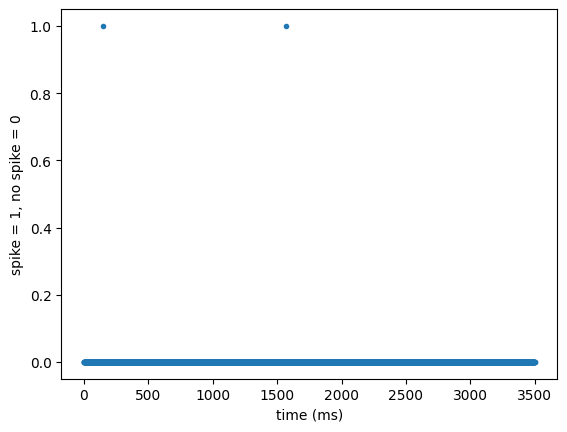

In [6]:
import matplotlib.pyplot as plt           # do not forget to load the plotting library

angle_idx = 1           # index of the 2nd angle is 1
trial_idx = 19          #index of the 20th trial is 19

plt.figure()
plt.plot(t_vect, spikes[angle_idx, :, trial_idx], '.') #One dimensional, we eliminated 2 of the dimensions by collapsing them
plt.xlabel('time (ms)')
plt.ylabel('spike = 1, no spike = 0')
plt.show()

Now let's make a raster plot that shows time on the x-axis and the spike trains of all trials on the y-axis. To do this, we want to do the same basic routine over and over again for each trial using a `for` loop, with the loop going from `1` to `n_trials`.

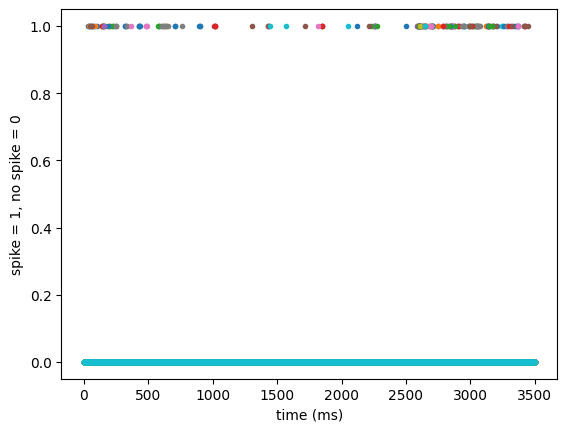

In [7]:
angle_idx = 1

plt.figure()
for trial_idx in range(n_trials): #Looping through all trials -1, range indexes at 0
    plt.plot(t_vect, spikes[angle_idx, :, trial_idx], '.')
plt.xlabel('time (ms)')
plt.ylabel('spike = 1, no spike = 0')
plt.show()

What is wrong with the above plot? When making plots like this, we want each trial to be located at a separate y-axis location so the responses do not lie on top of each other, so let's plot the first trial at `y=1`, the second at `y=2`, the 3rd at `y=3`, etc.

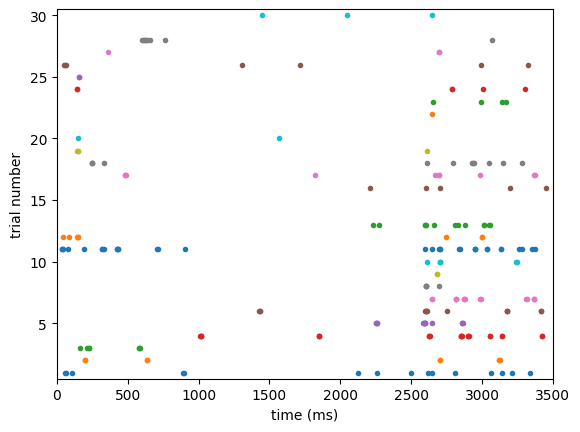

In [8]:
#This stimulus at this angle silenced this specific neurons, stimulus at 22.5 degrees

angle_idx = 1

plt.figure()
for trial_idx in range(n_trials):
    y_vals = (trial_idx + 1) * spikes[angle_idx, :, trial_idx] #
    plt.plot(t_vect, y_vals, '.')
plt.axis([0, 3500, 0.5, n_trials + 0.5]) # Hide's non-spiking plots
plt.xlabel('time (ms)')
plt.ylabel('trial number')
plt.show()

#Colors are reduntant, we all know theyre of the same neurons and our y axis defines our trial numbers as well.

# Peri-stimulus time histogram (PSTH)

The trial-to-trial variability in the response of this neuron is huge (e.g., compare trial 20 to trial 1, especially when the stimulus is off. This activity in the absence of a stimulus is called `background activity` or `baseline activity`). This is common for spike trains of cortical neurons. To get a better understanding of this neuron's typical response, it is helpful to average the data across trials and plot the trial-averaged firing rate of a neuron in response to a stimulus. When this trial-averaged firing rate is plotted as a histogram in time bins near (`peri`) the presentation of the stimulus, it is called a PSTH (which is short for peri-stimulus time histogram). Below we will learn how to create a PSTH for the set of trials of our data set corresponding to presentation of a particular angle, and thereby characterize the average firing rate response of the neuron to presentation of a stimulus at this angle.

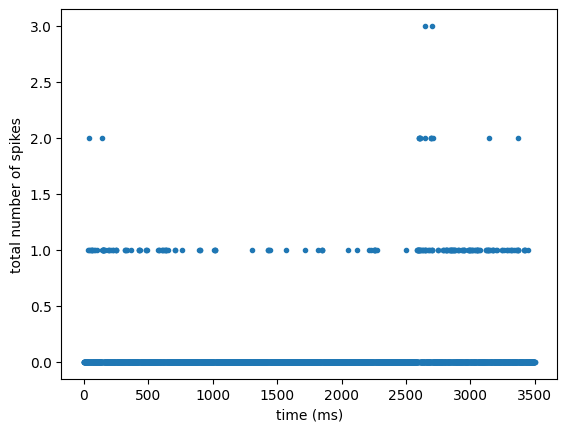

In [9]:
### sum across trials ###
angle_idx = 1
trial_sum_vect = np.sum(spikes[angle_idx, :, :], axis=1)  # trial is the third dimension so why are we not using axis=2?
# angle_idx removes it self from the array, therefore the time and trial are now a 2D array so trial has become the 2nd dimension thus axis = 1

plt.figure()
plt.plot(t_vect, trial_sum_vect, '.')
plt.xlabel('time (ms)')
plt.ylabel('total number of spikes')
plt.show()

The above plot shows the total number of spikes (summed across trials) at each time point. This is difficult to interpret without knowing how many trials there were. A more useful way to visualize would be to convert it to firing rate so we can express it in units of `spikes/s`.

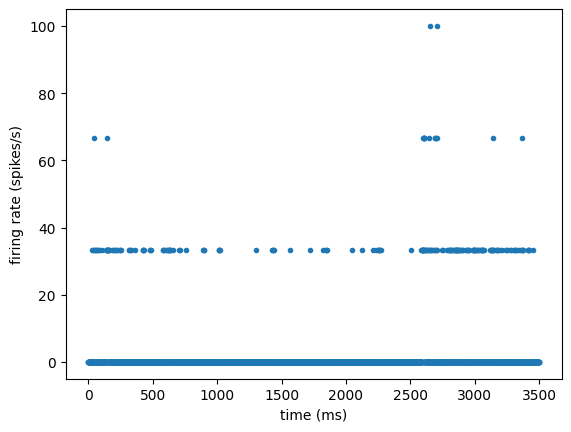

In [10]:
angle_idx = 1
trial_sum_vect = np.sum(spikes[angle_idx], axis=1)        # sum across trials
bin_width_s = dt / 1000
firing_rate = trial_sum_vect / (n_trials * bin_width_s)   # convert to firing rate (spikes/s)

plt.figure()
plt.plot(t_vect, firing_rate, '.')
plt.xlabel('time (ms)')
plt.ylabel('firing rate (spikes/s)')
plt.show()

Although our plot is technically correct, it's not very useful because it's very discontinuous. What we really need to do is to smooth this data by instead calculating the averages over a wider time bin such as 60 ms.

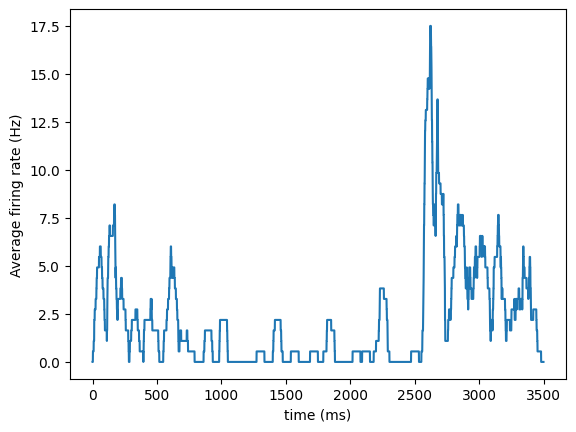

In [11]:
angle_idx = 1

# Sum across trials
trial_sum_vect = np.sum(spikes[angle_idx], axis=1)

# Smooth
smoothing_width = 61   # ±30 ms
kernel = np.ones(smoothing_width) / smoothing_width
trial_sum_smooth_vect = np.convolve(trial_sum_vect, kernel, mode='same')

# Convert to firing rate (spikes/s)
firing_rate = 1000 * trial_sum_smooth_vect / (n_trials * dt)

plt.figure()
plt.plot(t_vect, firing_rate)
plt.xlabel('time (ms)')
plt.ylabel('Average firing rate (Hz)')
plt.show()

# Exercise

Plot the smooth PSTH of this visual neuron for all orientations. You can plot all of them in the same figure.

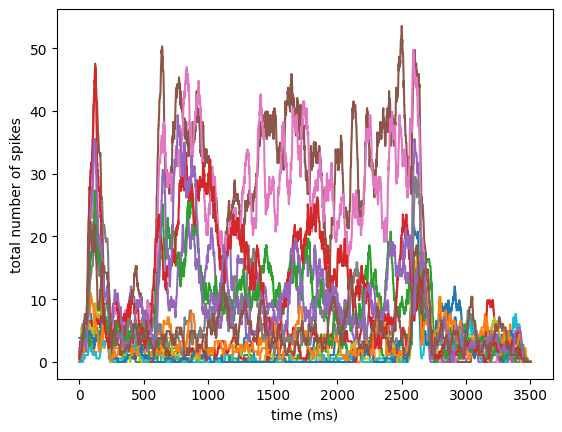

In [ ]:
plt.figure()
# Smooth
smoothing_width = 61   # ±30 ms
kernel = np.ones(smoothing_width) / smoothing_width

for angle_idx in np.arange(n_angles):
  trial_sum_vect = np.sum(spikes[angle_idx], axis=1)
  trial_sum_smooth_vect = np.convolve(trial_sum_vect, kernel, mode='same')
  firing_rate = 1000 * trial_sum_smooth_vect / (n_trials * dt)
  plt.plot(t_vect, firing_rate)

plt.xlabel('time (ms)')
plt.ylabel('total number of spikes')
plt.show()

# Tuning function

Finally, let's plot the tuning curve of this neuron. Recall that the tuning curve gives the average firing rate of the neuron across trials and over the duration of a stimulus, i.e. the average is over both time within the trial and across trials. Let's plot this tuning curve for the period of time when the stimulus is moving, which we recall is from 500 ms to 2500 ms.

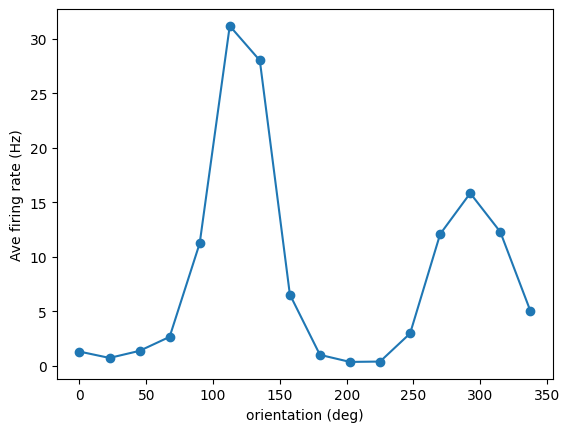

In [13]:
# Convert time to index
start_idx = int(t_Move / dt)
end_idx   = int(t_Off  / dt)

# Sum spikes across trials during motion period
tuning_counts_matrix = np.sum(spikes[:, start_idx:end_idx, :], axis=2)

# Sum across time
tuning_counts_vect = np.sum(tuning_counts_matrix, axis=1)

# Convert to average firing rate (Hz)
bin_width_s = dt / 1000
tuning_ave_rate_vect = tuning_counts_vect / ((t_Off - t_Move) * n_trials * bin_width_s)

# Orientation vector
delta_theta = 360 / n_angles
orientation_vect = np.arange(n_angles) * delta_theta

plt.figure()
plt.plot(orientation_vect, tuning_ave_rate_vect[:n_angles], 'o-')
plt.xlabel('orientation (deg)')
plt.ylabel('Ave firing rate (Hz)')
plt.show()

# Exercise

Add errorbars to the above plot

In [ ]:
# Convert time to index
start_idx = int(t_Move / dt)
end_idx   = int(t_Off  / dt)

# Sum spikes across trials during motion period
tuning_counts_matrix = np.sum(spikes[:, start_idx:end_idx, :], axis=2)

# Sum across time
tuning_counts_vect = np.sum(tuning_counts_matrix, axis=1)

# Convert to average firing rate (Hz)
bin_width_s = dt / 1000
tuning_ave_rate_vect = tuning_counts_vect / ((t_Off - t_Move) * n_trials * bin_width_s)

# Orientation vector
delta_theta = 360 / n_angles
orientation_vect = np.arange(n_angles) * delta_theta

plt.figure()
plt.plot(orientation_vect, tuning_ave_rate_vect[:n_angles], 'o-')
plt.xlabel('orientation (deg)')
plt.ylabel('Ave firing rate (Hz)')
plt.show()